In [1]:
# Import packages

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D

In [2]:
def replace_legend_label(label):
    strain_labels = {
        '177': 'WT',
        '232': r'$\Delta\mathit{pilH}$',
        '459': r'$\Delta\mathit{pilG}$'
    }
    return strain_labels.get(label, label)

In [5]:
# USER INPUT: Folder paths

data_folder = "/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/nematic_correlation_plot/dataset"  # Folder where the CSV files are located
figures_folder = "/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/nematic_correlation_plot/figures"  # Folder where figures will be saved

## Plot nematic correlation function

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_66065/1348434975.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("tab20", len(dfs))


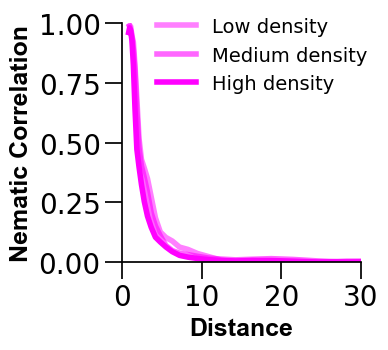

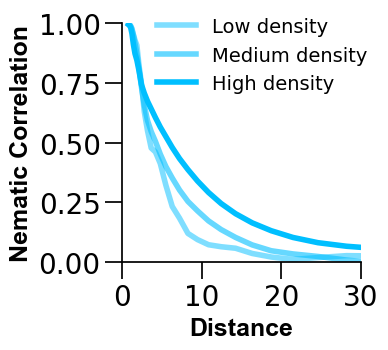

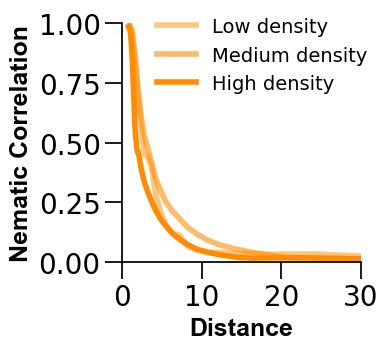

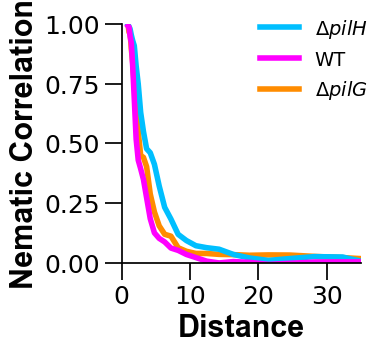

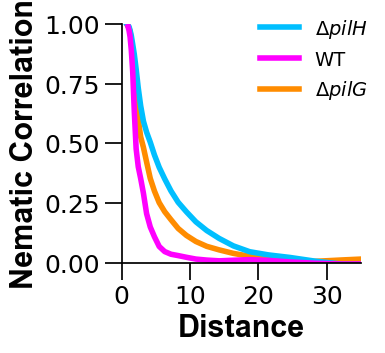

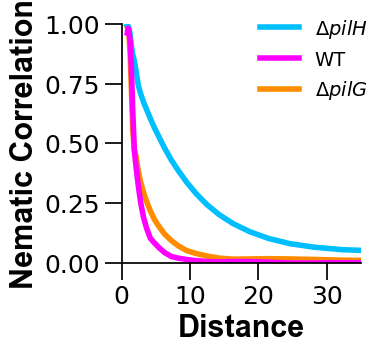

In [8]:
## Plot mean nematic correlation as a function of distance (normalized by bacterial width)

# Bacterial width (in µm)
bacterial_width = 0.8  

# Define colors for strains
strain_colors = {
    "177": "magenta",
    "232": "deepskyblue",
    "459": "darkorange"
}

# Surface coverage and strains options
sc_options = ["SC10pc", "SC30pc", "SC70pc"]
strains_to_plot = ["177", "232", "459"]

# Option for plotting individual curves: "gray" or "colors"
plot_single_curves_in_gray = True 

# Step 1: Load the data and group by strain and SC
data_by_strain_sc = {}  # Dictionary to hold data grouped by strain and SC
files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

for file in files:
    filepath = os.path.join(data_folder, file)
    try:
        df = pd.read_csv(filepath)
        df = df.dropna()
        df = df.sort_values(by="radius")

        # Normalize radius by bacterial width
        df["radius"] = df["radius"] / bacterial_width

        # Compute the average for each radius (to smooth individual curves)
        df = df.groupby("radius", as_index=False)["nematic_correlation"].mean()

        # Extract strain and SC from filename
        strain_found = None
        sc_found = None

        # Extract strain (appears after the date in the format yymmdd_strain)
        for strain in ["177", "232", "459"]:
            if strain in file.split('_')[1][0:3]:
                strain_found = strain
                #print(strain)
                break

        # Extract surface coverage (eg _SC10pc)
        for sc in sc_options:
            if sc in file:
                sc_found = sc
                #print(sc)
                break

        # Ensure both strain and SC are found before adding the data
        if strain_found and sc_found:
            key = (strain_found, sc_found)
            if key not in data_by_strain_sc:
                data_by_strain_sc[key] = []
            data_by_strain_sc[key].append((df, file))
        else:
            print(f"Skipping file {file} as it doesn't match a known strain or SC.")

    except Exception as e:
        print(f"Error loading file {file}: {e}")

# Step 2: Plot individual and average curves per strain and SC
for (strain, sc), dfs in data_by_strain_sc.items():
    plt.figure(figsize=(5, 5))
    colormap = cm.get_cmap("tab20", len(dfs))

    for i, (df, file) in enumerate(dfs):
        color = "gray" if plot_single_curves_in_gray else colormap(i)
        plt.plot(
            df["radius"],
            df["nematic_correlation"],
            color=color,
            alpha=0.7,
            linewidth=1.5,
            label=file[:10] + '_' + sc + '_' + file[42:58]
        )

    combined_data = pd.concat([df for df, _ in dfs])
    avg_curve = combined_data.groupby("radius")["nematic_correlation"].mean()
    plt.plot(
        avg_curve.index,
        avg_curve.values,
        color=strain_colors[strain],
        linewidth=6,
        label=f"Average - {replace_legend_label(strain)} - {sc}"
    )

    plt.title(f"{replace_legend_label(strain)} - {sc}")
    plt.ylim(0, 1)
    plt.xlim(0, 30)
    plt.xlabel("Distance")
    plt.ylabel("Nematic Correlation")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(figures_folder, f"strain_{strain}_{sc}.png"))
    plt.close()

# Step 3: Plot average curves per strain for all SCs
for strain in strains_to_plot:
    plt.figure(figsize=(4,4))
    for sc in sc_options:
        key = (strain, sc)
        if key in data_by_strain_sc:
            dfs = data_by_strain_sc[key]
            combined_data = pd.concat([df for df, _ in dfs])
            avg_curve = combined_data.groupby("radius")["nematic_correlation"].mean()
            alpha_value = 1.0 if sc == "SC70pc" else 0.6 if sc == "SC30pc" else 0.5
            label_text = "Low density" if sc == "SC10pc" else "High density" if sc == "SC70pc" else "Medium density"
            plt.plot(
                avg_curve.index,
                avg_curve.values,
                color=strain_colors[strain],
                linewidth=4,
                alpha=alpha_value,
                label=label_text
            )
    plt.ylim(0, 1)
    plt.xlim(0, 30)
    plt.xlabel("Distance", fontsize=18, fontweight='bold', fontname='Arial')
    plt.ylabel("Nematic Correlation", fontsize=18, fontweight='bold', fontname='Arial')
    plt.xticks(ticks=[0, 10, 20, 30], fontsize=20)
    plt.yticks(ticks=[0.0, 0.25, 0.5, 0.75, 1], fontsize=20)
    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([0.25, 0.75]))
    plt.gca().tick_params(axis='both', which='major', length=12, width=1.25, color='black')
    plt.legend(loc='upper right', fontsize=14, frameon = False, bbox_to_anchor=(1.1, 1.1))
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_linewidth(1.25)
    plt.gca().spines['bottom'].set_linewidth(1.25)
    plt.gca().set_box_aspect(1)
    plt.tight_layout()
    plt.savefig(os.path.join(figures_folder, f"average_strain_{strain}_all_SCs.png"), dpi=300, transparent=True)

# Step 4: Plot average curves per SC across selected strains
plot_order = ["459", "232", "177"]
legend_order = ["232", "177", "459"]

for sc in sc_options:
    fig, ax = plt.subplots(figsize=(4,4))
    for strain in plot_order:
        if strain not in strains_to_plot:
            continue
        key = (strain, sc)
        if key in data_by_strain_sc:
            dfs = data_by_strain_sc[key]
            combined_data = pd.concat([df for df, _ in dfs])
            avg_curve = combined_data.groupby("radius")["nematic_correlation"].mean()
            ax.plot(
                avg_curve.index,
                avg_curve.values,
                color=strain_colors[strain],
                linewidth=4,
                label=replace_legend_label(strain)
            )

    legend_elements = []
    for strain in legend_order:
        if strain in strains_to_plot:
            legend_elements.append(
                Line2D([0], [0], color=strain_colors[strain], lw=4, label=replace_legend_label(strain))
            )
    ax.legend(handles=legend_elements, loc='upper right', fontsize=14, frameon=False, bbox_to_anchor=(1.1, 1.1))
    ax.set_xlim(0, 35)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel("Distance", fontsize=22, fontweight='bold', fontname='Arial')
    ax.set_ylabel("Nematic Correlation", fontsize=22, fontweight='bold', fontname='Arial')
    ax.set_xticks([0, 10, 20, 30])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1])
    plt.gca().tick_params(axis='both', which='major', length=12, width=1.25, color='black')  # Major ticks
    ax.tick_params(labelsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.25)
    ax.spines['bottom'].set_linewidth(1.25)
    fig.tight_layout()
    plt.savefig(os.path.join(figures_folder, f"average_all_strains_norm_{sc}.png"), transparent=True, dpi=300)
    
    # Save figures
    fig.savefig(os.path.join(figures_folder, f"average_all_strains_norm_{sc}.png"), transparent=True, dpi=300)
    plt.show()
